How we split input text into individual tokens, a required pre-processing step for creating embeddings for an LLM.

## Tokenize Text:

    - These tokens are either individual words or special characters including punctuations characters


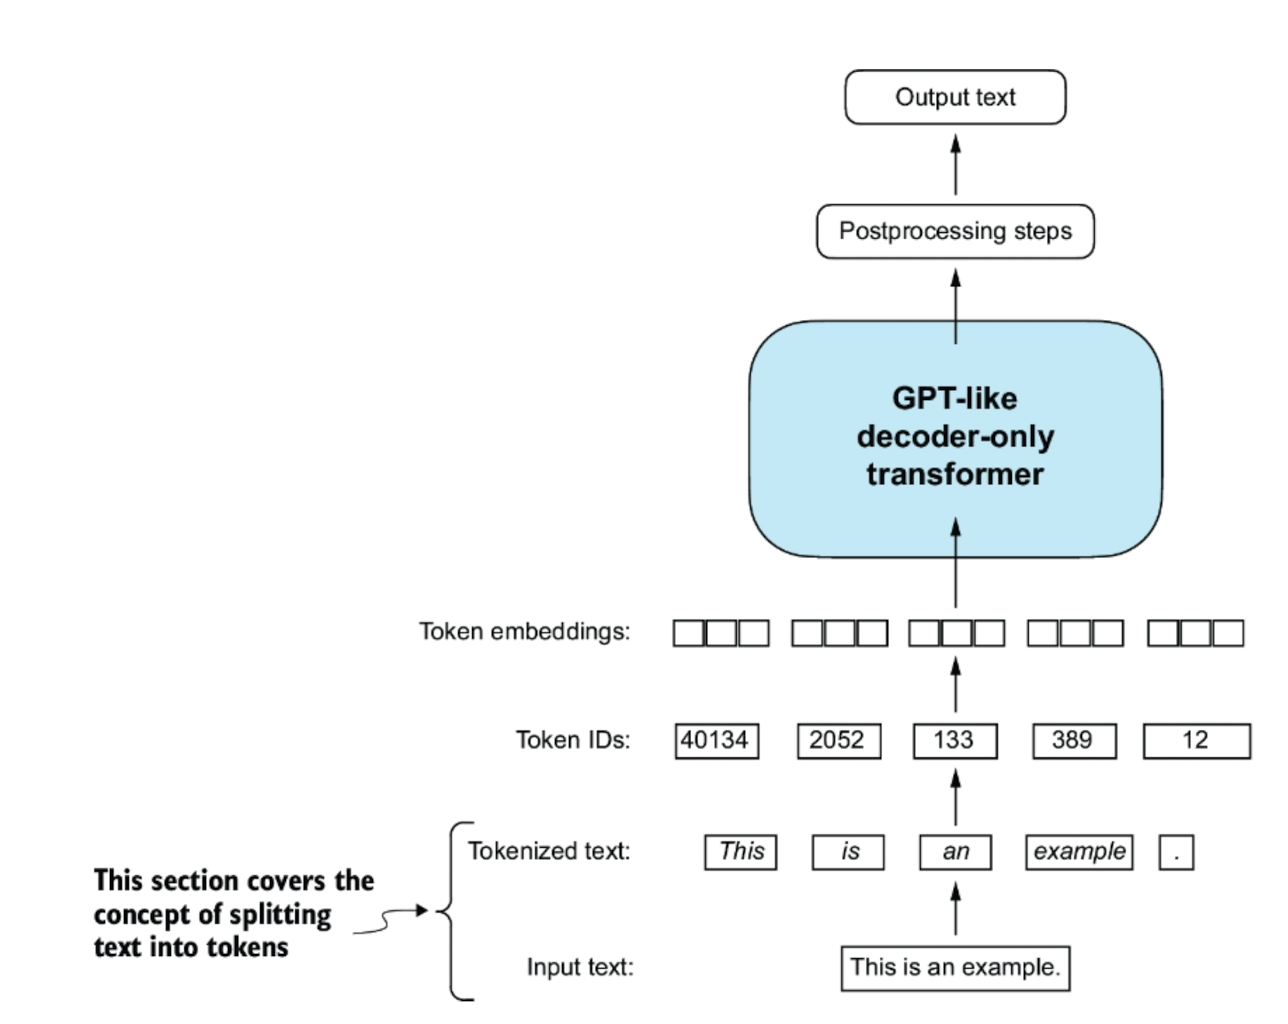

In [49]:
#Input_Text: https://en.wikisource.org/wiki/The_Verdict



In [50]:
import re

In [51]:
with open("./Data/the-verdict.txt","r", encoding='utf-8') as f:
    raw_text = f.read()


print(f"Total no.of characters:{len(raw_text)}")
print(f"lets look into a few chars: {raw_text[:100]}")

Total no.of characters:20479
lets look into a few chars: I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no g


## Prepare Vocab

In [52]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed[:30]

['I',
 ' ',
 'HAD',
 ' ',
 'always',
 ' ',
 'thought',
 ' ',
 'Jack',
 ' ',
 'Gisburn',
 ' ',
 'rather',
 ' ',
 'a',
 ' ',
 'cheap',
 ' ',
 'genius',
 '--',
 'though',
 ' ',
 'a',
 ' ',
 'good',
 ' ',
 'fellow',
 ' ',
 'enough',
 '--']

In [53]:

#just removing the empty spaces
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(len(preprocessed))


4690


In [54]:
preprocessed[:30]

['I',
 'HAD',
 'always',
 'thought',
 'Jack',
 'Gisburn',
 'rather',
 'a',
 'cheap',
 'genius',
 '--',
 'though',
 'a',
 'good',
 'fellow',
 'enough',
 '--',
 'so',
 'it',
 'was',
 'no',
 'great',
 'surprise',
 'to',
 'me',
 'to',
 'hear',
 'that',
 ',',
 'in']

In [55]:
all_words = sorted(set(preprocessed))
vocab_size = len(all_words)
print(vocab_size)

1130


In [56]:
vocab = {
    token:idx 
    for idx, token in enumerate(all_words)
}

for i,item in enumerate(vocab.items()):
    print(item)
    if i>=50:
        break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Chicago', 25)
('Claude', 26)
('Come', 27)
('Croft', 28)
('Destroyed', 29)
('Devonshire', 30)
('Don', 31)
('Dubarry', 32)
('Emperors', 33)
('Florence', 34)
('For', 35)
('Gallery', 36)
('Gideon', 37)
('Gisburn', 38)
('Gisburns', 39)
('Grafton', 40)
('Greek', 41)
('Grindle', 42)
('Grindles', 43)
('HAD', 44)
('Had', 45)
('Hang', 46)
('Has', 47)
('He', 48)
('Her', 49)
('Hermia', 50)


## Simple Tokenizer

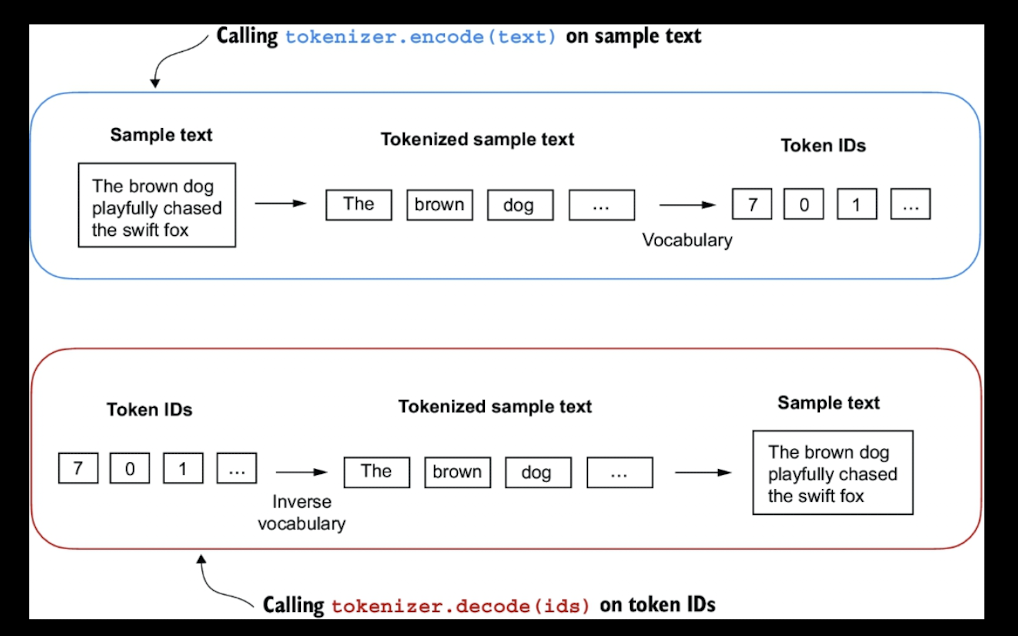

In [57]:
import re

class simpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.into_to_str = {i:s for s,i in vocab.items()}
    
    def encode(self, text):
        preprocessed = re.split(
            r'([,.:;?_!"()\']|--|\s)',
            text
        )
        preprocessed=[
            item.strip() for item
            in preprocessed 
            if item.strip()
        ]
        print(f"before converting words to ids\n{preprocessed}")
        ids=[
            self.str_to_int[s] for s in preprocessed
        ]
        return ids
    
    def decode(self, ids):
        text = " ".join(
            [
                self.into_to_str[id]
                for id in ids
            ]
        )
        print(f"before converint ids to text..\n{text}")
        text=re.sub(r'\s+([,.?!"()\'])', r'\1', text)

        return text


In [58]:
#Now apply to our entire text file

tokenizer=simpleTokenizerV1(vocab=vocab)

ids = tokenizer.encode(
    text=""""It's the last he painted, you know," Mrs. Gisburn said with pardonable pride."""
)
print(ids)

before converting words to ids
['"', 'It', "'", 's', 'the', 'last', 'he', 'painted', ',', 'you', 'know', ',', '"', 'Mrs', '.', 'Gisburn', 'said', 'with', 'pardonable', 'pride', '.']
[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [59]:
text = tokenizer.decode(
    ids=ids
)

before converint ids to text..
" It ' s the last he painted , you know , " Mrs . Gisburn said with pardonable pride .


#### Next apply a tokenization to the new text sample not contained in the training set

- The following code will throw an error due to
    - "Hello" was not cotained in the our vocabulary(vocab)

- `This highlight the need to consider large and divers training sets to extend the vocabulary when working on LLMs` 

In [60]:
print(
    tokenizer.encode("Hello, do you like tea?")
)

before converting words to ids
['Hello', ',', 'do', 'you', 'like', 'tea', '?']


KeyError: 'Hello'

### Adding Special Context Tokens

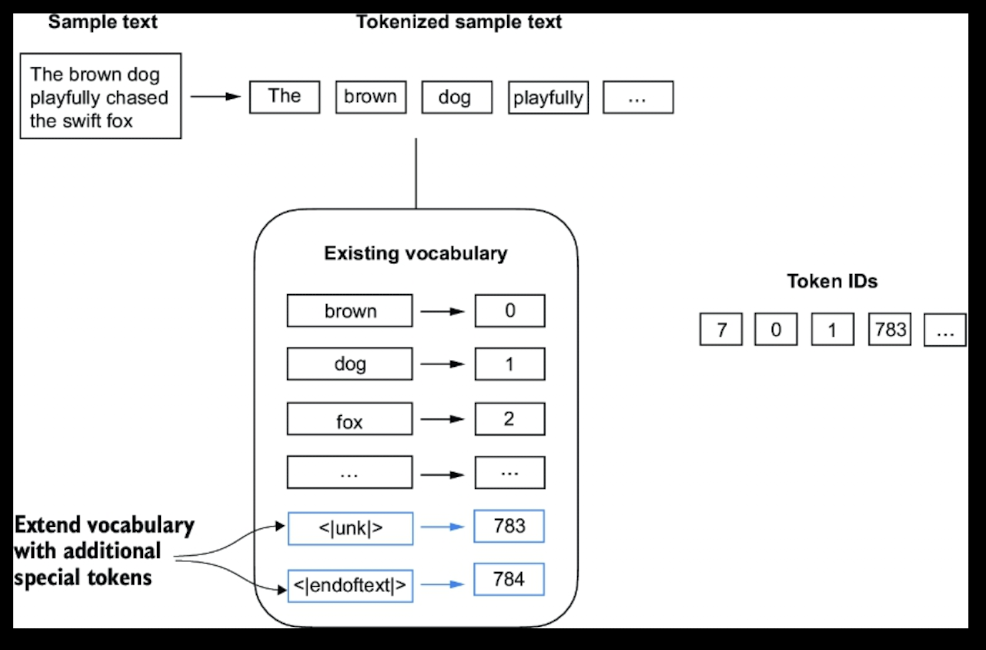

- As we seen above if the tokenizer try to tokenize the unseen words its throwing an error

- Instead, we need to handle the unknown words

- And also, need to address the usage and addition of special context tokens that can enhance models understanding of context or relevant information in the text

- The special tokens can be incldue `markers for unknown words and document boundaries`

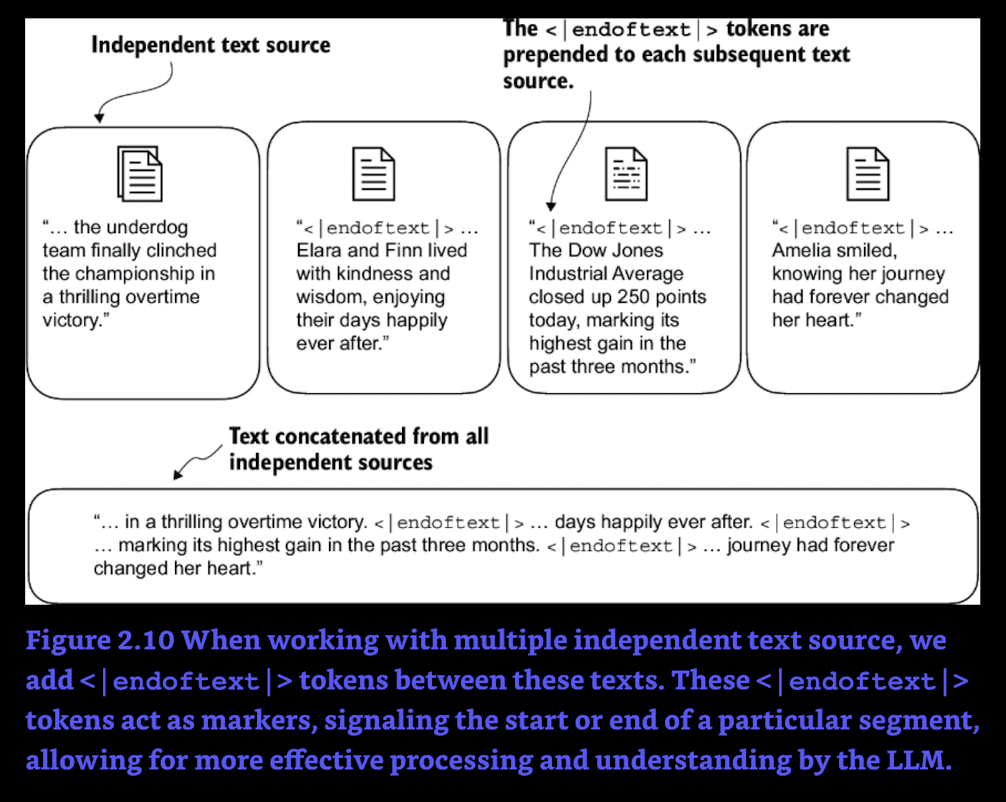

In [98]:
# Lets now modify the vocabulary to include 
# these two special tokens <unk> and <|endoftext|>
# by adding them to our list of all unique words


all_tokens=sorted(
    list(set(preprocessed))
)

In [99]:
all_tokens.extend(["<|endoftext|>", "<|unk|>"])

In [100]:
all_tokens[-3:]

['yourself', '<|endoftext|>', '<|unk|>']

In [101]:
vocab = {
    token:idx
    for idx, token 
    in enumerate(all_tokens)
}

In [102]:
for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


In [103]:
class SimpleTokenizerV2:
    def __init__(self,vocab):
        self.str_to_int = vocab
        self.int_to_str = {
            i:s
            for s,i in vocab.items()
        }
    
    def encode(self,text):
        preprocessed=re.split(
            r'([,.:;?_!"()\']|--|\s)',
            text
        )
        preprocessed=[
            item.strip()
            for item in preprocessed
            if item.strip()
        ]
        preprocessed=[
            item if item in self.str_to_int
            else "<|unk|>" for item in preprocessed
        ]
        ids=[
            self.str_to_int[s] for s in preprocessed
        ]
        return ids
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)    
        return text


In [104]:
#Test Input
text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
text = " <|endoftext|> ".join((text1, text2))
print(text)


Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [105]:
vocab["<|endoftext|>"]

1130

In [106]:
tokenizer_v2 = SimpleTokenizerV2(vocab=vocab)
ids=tokenizer_v2.encode(text)
print(ids)

[1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 984, 722, 988, 1131, 7]


In [107]:
print(tokenizer_v2.decode(ids))

<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.


# Depending on the LLM, some researchers also consider additional special tokens such as following

- [BOS] (beginning of sequence): This token marks the start of the text. It signifies to the LLM where a piece of content begins

- [EOS] (end of sequence): This token is positioned at the end of a text and is especially useful when concatenating multiple unrelated texts, similar to <|endoftext|>. For instance, when combining two different wikipedia article or books, the [EOS] token indicates where one ends and the next begins

- [PAD] (padding): When training LLMs with batch sizes larger than one, the batch might contain texts of varing lengths. To ensure all texts have the same length, the shorter texts are extended or "padded" using the [PAD] token, up to the lenght of the longest text in the batch